In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### FAOSTAT Kenya Agricultural Data EDA

In [5]:
# https://www.fao.org/faostat/en/#data/QCL

In [6]:
# Load FAOSTAT data
# faostat_df = pd.read_csv("FAOSTAT_data_en_1-29-2026.csv")
faostat_df = pd.read_csv("FAOSTAT_data_en_3-2-2026.csv")

print("Dataset Shape:", faostat_df.shape)
print("\nFirst few rows:")
print(faostat_df.head())
print("\nColumn names and types:")
print(faostat_df.dtypes)

Dataset Shape: (1689, 15)

First few rows:
  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              404  Kenya   
1         QCL  Crops and livestock products              404  Kenya   
2         QCL  Crops and livestock products              404  Kenya   
3         QCL  Crops and livestock products              404  Kenya   
4         QCL  Crops and livestock products              404  Kenya   

   Element Code         Element  Item Code (CPC)                     Item  \
0          5312  Area harvested          1929.07  Abaca, manila hemp, raw   
1          5412           Yield          1929.07  Abaca, manila hemp, raw   
2          5312  Area harvested          1929.07  Abaca, manila hemp, raw   
3          5412           Yield          1929.07  Abaca, manila hemp, raw   
4          5312  Area harvested          1929.07  Abaca, manila hemp, raw   

   Year Code  Year   Unit   Value Flag Flag Description Note  
0   

In [7]:
faostat_df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='str')

In [8]:
faostat_df['Year Code'].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

Missing Values per Column:
Value       1
Note     1666
dtype: int64

Total missing values: 1667
Missing percentage: 6.58%


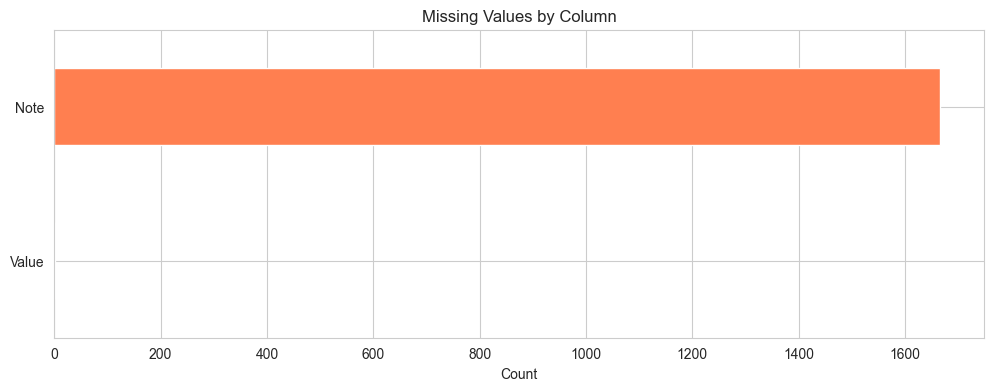

In [9]:
# Missing values analysis
print("Missing Values per Column:")
missing = faostat_df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing values: {faostat_df.isnull().sum().sum()}")
print(f"Missing percentage: {(faostat_df.isnull().sum().sum() / faostat_df.size) * 100:.2f}%")

# Visualize missing values
plt.figure(figsize=(12, 4))
missing_data = faostat_df.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    missing_data.plot(kind='barh', color='coral')
    plt.title("Missing Values by Column")
    plt.xlabel("Count")
    plt.show()
else:
    print("No missing values found!")

In [10]:
# Key categorical variables
print("=== Unique Values Analysis ===\n")
print(f"Elements (Metrics): {faostat_df['Element'].unique()}")
print(f"Number of unique Items (Crops): {faostat_df['Item'].nunique()}")
print(f"Years covered: {sorted(faostat_df['Year'].unique())}")
print(f"Units used: {faostat_df['Unit'].unique()}")
print(f"\nFlag types (data quality):")
print(faostat_df['Flag'].value_counts())

=== Unique Values Analysis ===

Elements (Metrics): <StringArray>
['Area harvested', 'Yield']
Length: 2, dtype: str
Number of unique Items (Crops): 85
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Units used: <StringArray>
['ha', 'kg/ha']
Length: 2, dtype: str

Flag types (data quality):
Flag
A    971
E    457
I    216
X     44
M      1
Name: count, dtype: int64


In [11]:
# Statistical summary
print("=== Statistical Summary ===\n")
print(faostat_df['Value'].describe())

print("\n\nTop 10 Crops by Data Points:")
print(faostat_df['Item'].value_counts().head(10))

print("\n\nData Points by Element:")
print(faostat_df['Element'].value_counts())

=== Statistical Summary ===

count    1.688000e+03
mean     3.991629e+04
std      1.966581e+05
min      1.000000e+00
25%      9.185750e+02
50%      5.438500e+03
75%      1.401888e+04
max      2.430014e+06
Name: Value, dtype: float64


Top 10 Crops by Data Points:
Item
Abaca, manila hemp, raw                                                      20
Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw    20
Apples                                                                       20
Apricots                                                                     20
Artichokes                                                                   20
Asparagus                                                                    20
Avocados                                                                     20
Bananas                                                                      20
Barley                                                                       20
Beans, dry 

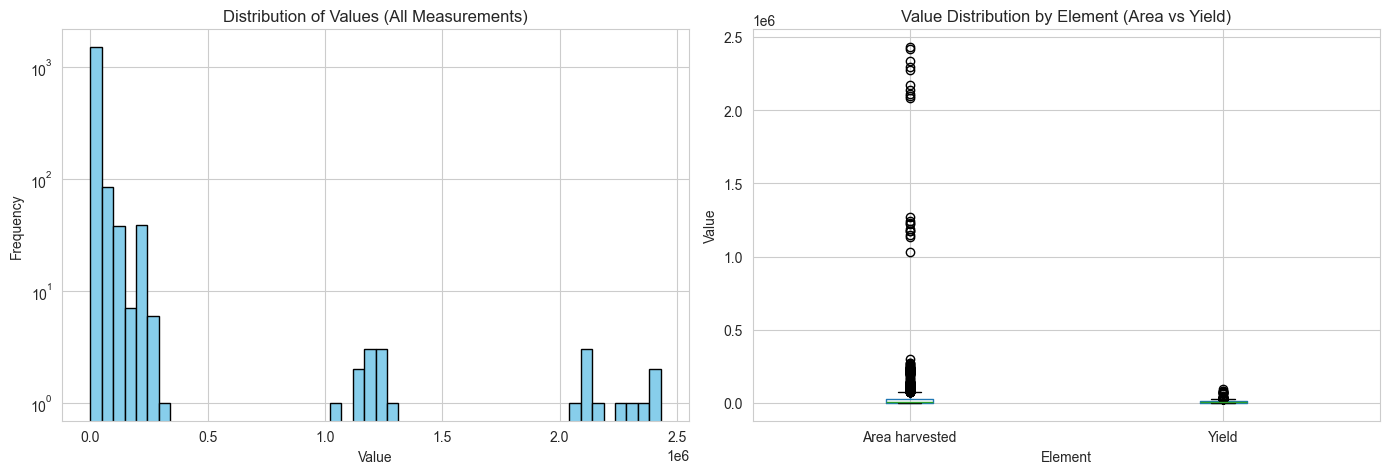

In [12]:
# Distribution of Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(faostat_df['Value'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Values (All Measurements)')
axes[0].set_yscale('log')

# Box plot by Element
faostat_df.boxplot(column='Value', by='Element', ax=axes[1])
axes[1].set_title('Value Distribution by Element (Area vs Yield)')
axes[1].set_xlabel('Element')
axes[1].set_ylabel('Value')
plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

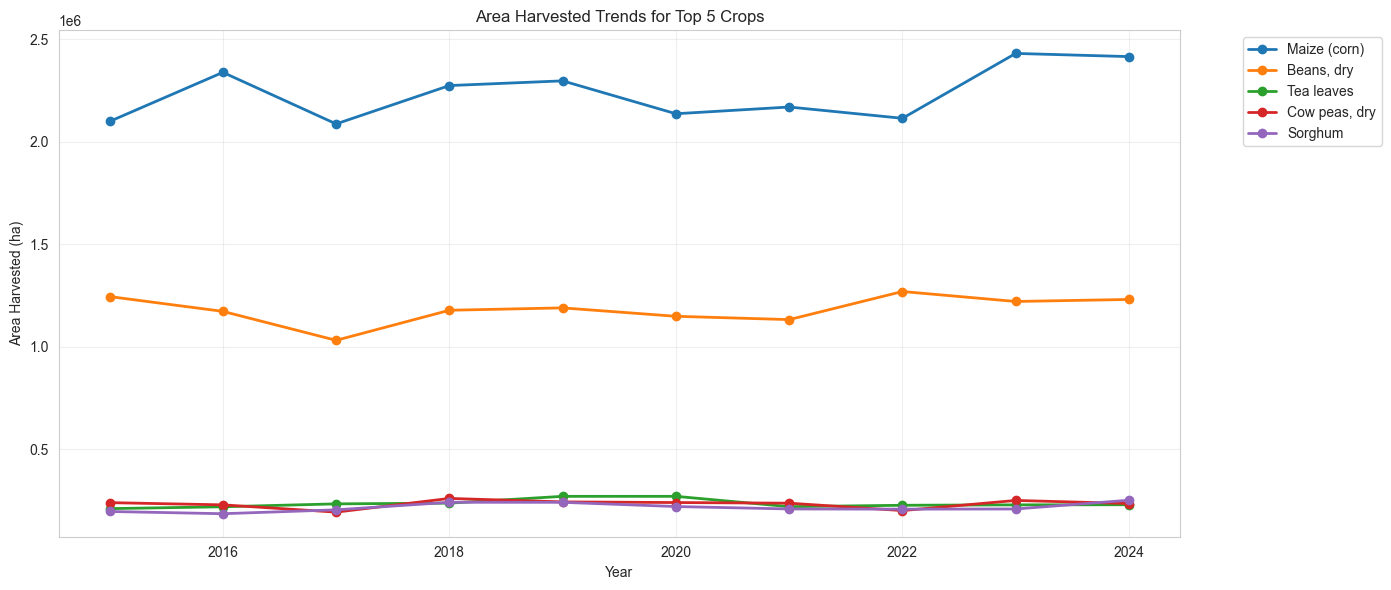

In [13]:
# Time series trends - Top 5 crops by area harvested
top_crops_area = faostat_df[faostat_df['Element'] == 'Area harvested'].groupby('Item')['Value'].sum().nlargest(5).index

plt.figure(figsize=(14, 6))
for crop in top_crops_area:
    crop_data = faostat_df[(faostat_df['Item'] == crop) & (faostat_df['Element'] == 'Area harvested')]
    crop_data = crop_data.sort_values('Year')
    plt.plot(crop_data['Year'], crop_data['Value'], marker='o', label=crop, linewidth=2)

plt.xlabel('Year')
plt.ylabel('Area Harvested (ha)')
plt.title('Area Harvested Trends for Top 5 Crops')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

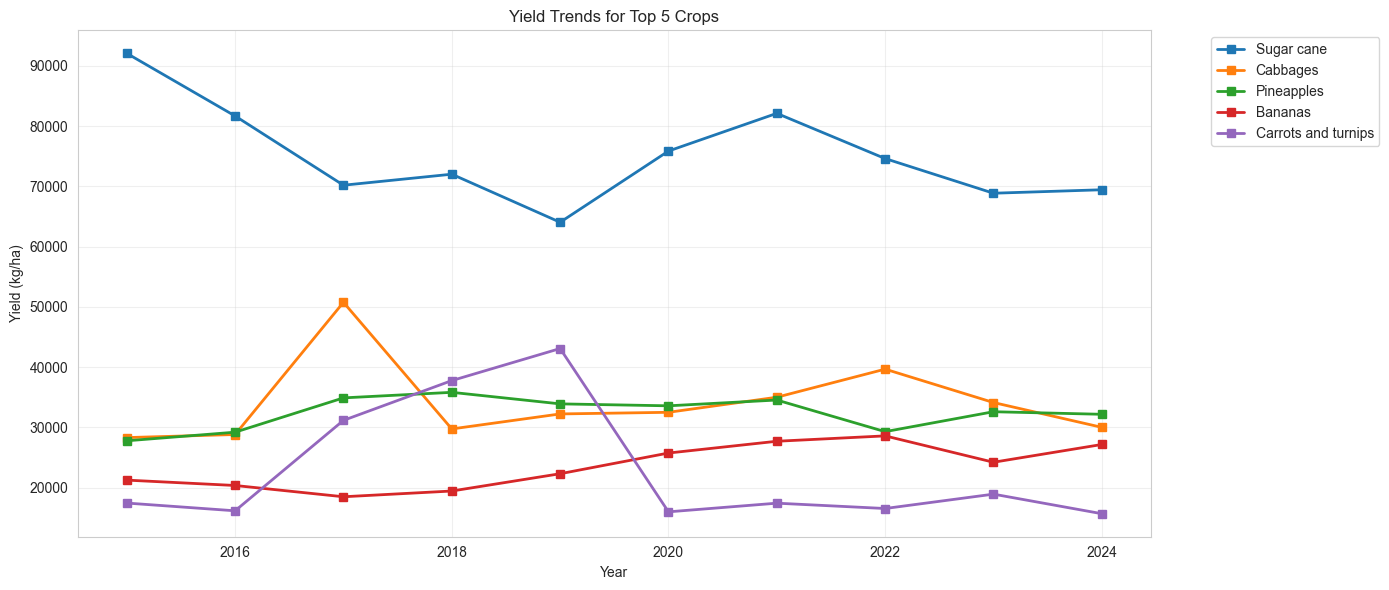

In [14]:
# Time series trends - Top 5 crops by Yield
top_crops_yield = faostat_df[faostat_df['Element'] == 'Yield'].groupby('Item')['Value'].sum().nlargest(5).index

plt.figure(figsize=(14, 6))
for crop in top_crops_yield:
    crop_data = faostat_df[(faostat_df['Item'] == crop) & (faostat_df['Element'] == 'Yield')]
    crop_data = crop_data.sort_values('Year')
    plt.plot(crop_data['Year'], crop_data['Value'], marker='s', label=crop, linewidth=2)

plt.xlabel('Year')
plt.ylabel('Yield (kg/ha)')
plt.title('Yield Trends for Top 5 Crops')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

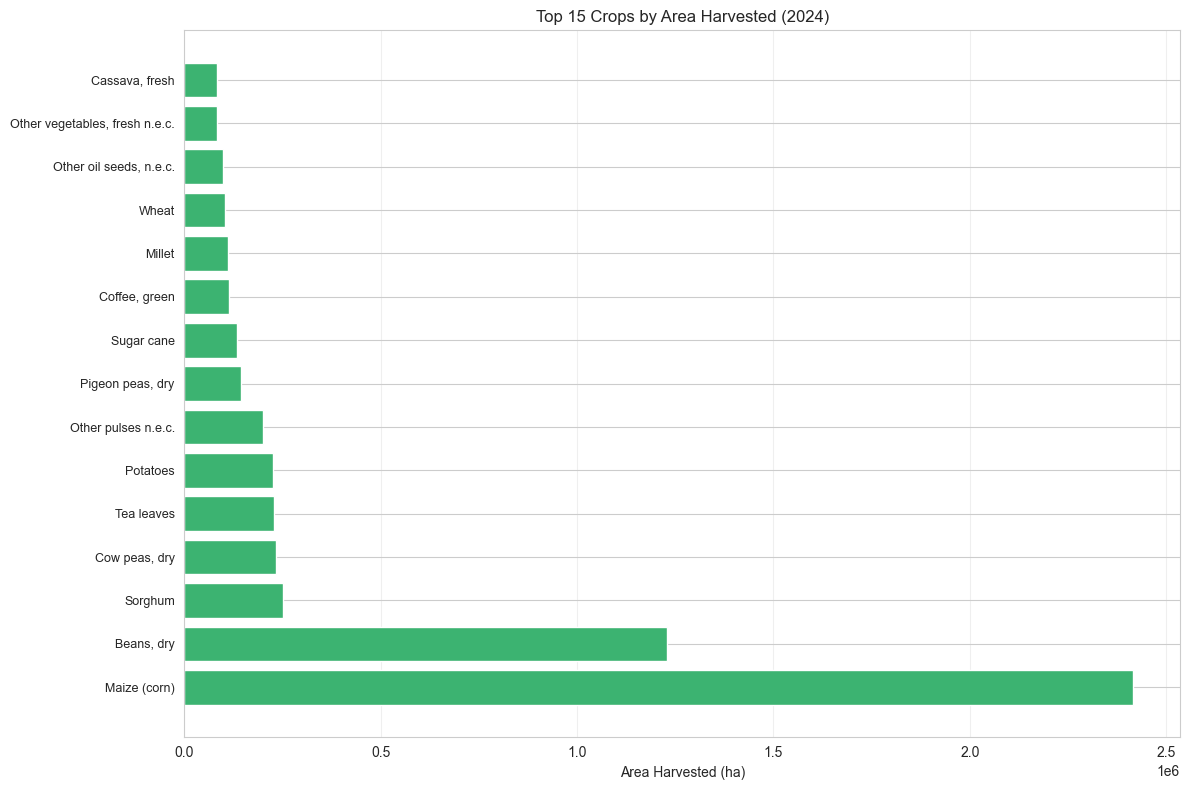

In [15]:
# Top 15 crops by total area harvested (2024 data)
latest_year = faostat_df['Year'].max()
area_2024 = faostat_df[(faostat_df['Element'] == 'Area harvested') & (faostat_df['Year'] == latest_year)]
top_area = area_2024.nlargest(15, 'Value')

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_area)), top_area['Value'].values, color='mediumseagreen')
plt.yticks(range(len(top_area)), top_area['Item'].values, fontsize=9)
plt.xlabel('Area Harvested (ha)')
plt.title(f'Top 15 Crops by Area Harvested ({latest_year})')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

=== Data Quality Analysis ===

Flag Distribution (Data Quality Indicators):
Flag
A    971
E    457
I    216
X     44
M      1
Name: count, dtype: int64

Flag Descriptions:
  E: Estimated value
  I: Value imputed by a receiving agency
  A: Official figure
  X: Figure from external organization
  M: Missing value; data cannot exist


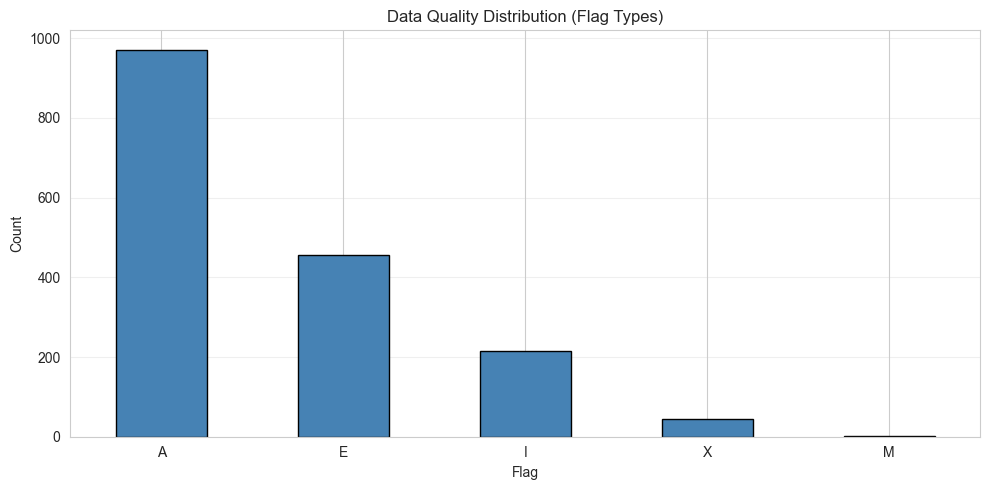

In [16]:
# Data Quality Analysis
print("=== Data Quality Analysis ===\n")
print("Flag Distribution (Data Quality Indicators):")
flag_counts = faostat_df['Flag'].value_counts()
print(flag_counts)
print("\nFlag Descriptions:")
flag_desc = faostat_df[['Flag', 'Flag Description']].drop_duplicates()
for _, row in flag_desc.iterrows():
    print(f"  {row['Flag']}: {row['Flag Description']}")

# Visualize flag distribution
plt.figure(figsize=(10, 5))
flag_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Data Quality Distribution (Flag Types)')
plt.xlabel('Flag')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

=== Correlation between Area Harvested and Yield ===

Correlation (log-scaled): -0.143


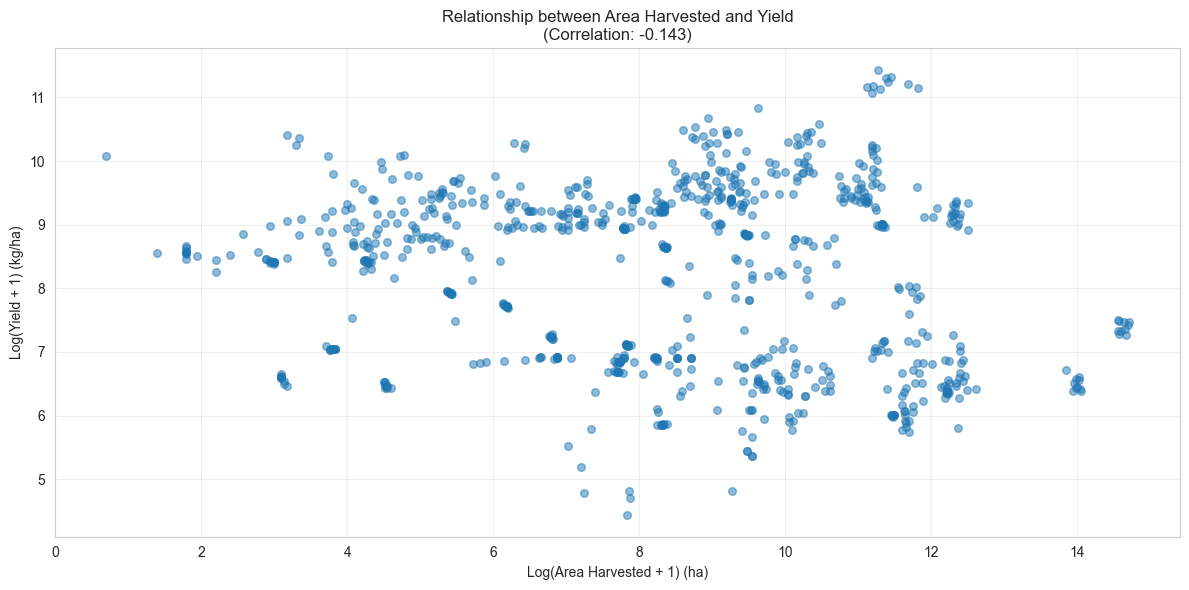

In [17]:
# Correlation between Area Harvested and Yield for top crops
# Pivot data to have Area and Yield in separate columns
pivot_data = faostat_df.pivot_table(
    values='Value', 
    index=['Item', 'Year'], 
    columns='Element', 
    aggfunc='first'
).reset_index()

# Calculate correlation for crops with both metrics
print("=== Correlation between Area Harvested and Yield ===\n")
pivot_data['log_area'] = np.log1p(pivot_data['Area harvested'])
pivot_data['log_yield'] = np.log1p(pivot_data['Yield'])

correlation = pivot_data[['log_area', 'log_yield']].corr().iloc[0, 1]
print(f"Correlation (log-scaled): {correlation:.3f}")

# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(pivot_data['log_area'], pivot_data['log_yield'], alpha=0.5, s=30)
plt.xlabel('Log(Area Harvested + 1) (ha)')
plt.ylabel('Log(Yield + 1) (kg/ha)')
plt.title(f'Relationship between Area Harvested and Yield\n(Correlation: {correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Summary Insights
print("=== KEY INSIGHTS FROM FAOSTAT KENYA DATA ===\n")

print(f"1. DATASET SIZE:")
print(f"   - Total records: {len(faostat_df):,}")
print(f"   - Unique crops: {faostat_df['Item'].nunique()}")
print(f"   - Time span: {faostat_df['Year'].min()}-{faostat_df['Year'].max()}")
print(f"   - Metrics: {', '.join(faostat_df['Element'].unique())}")

print(f"\n2. DATA COMPLETENESS:")
print(f"   - Missing values: {faostat_df.isnull().sum().sum()} ({(faostat_df.isnull().sum().sum()/faostat_df.size)*100:.2f}%)")
print(f"   - Data quality mostly: Official figures ({(faostat_df[faostat_df['Flag']=='A'].shape[0]/len(faostat_df)*100):.1f}%)")

print(f"\n3. AGRICULTURAL FOCUS:")
area_stats = faostat_df[faostat_df['Element'] == 'Area harvested']['Value'].describe()
yield_stats = faostat_df[faostat_df['Element'] == 'Yield']['Value'].describe()
print(f"   - Area harvested: {area_stats['min']:.0f} - {area_stats['max']:.0f} ha (mean: {area_stats['mean']:.0f} ha)")
print(f"   - Yield: {yield_stats['min']:.0f} - {yield_stats['max']:.0f} kg/ha (mean: {yield_stats['mean']:.0f} kg/ha)")

print(f"\n4. TOP CROPS (by area harvested in {latest_year}):")
for i, (crop, value) in enumerate(area_2024.nlargest(5, 'Value')[['Item', 'Value']].values, 1):
    print(f"   {i}. {crop}: {value:,.0f} ha")

print(f"\n5. RECOMMENDATIONS FOR ANALYSIS:")
print(f"   - Filter by Element (Area harvested or Yield) for specific analysis")
print(f"   - Consider log-transforming values due to high variance")
print(f"   - Account for data quality flags (A=official, E=estimated, I=imputed)")
print(f"   - Group by crop type for commodity-specific trends")

=== KEY INSIGHTS FROM FAOSTAT KENYA DATA ===

1. DATASET SIZE:
   - Total records: 1,689
   - Unique crops: 85
   - Time span: 2015-2024
   - Metrics: Area harvested, Yield

2. DATA COMPLETENESS:
   - Missing values: 1667 (6.58%)
   - Data quality mostly: Official figures (57.5%)

3. AGRICULTURAL FOCUS:
   - Area harvested: 1 - 2430014 ha (mean: 71581 ha)
   - Yield: 84 - 92057 kg/ha (mean: 8251 kg/ha)

4. TOP CROPS (by area harvested in 2024):
   1. Maize (corn): 2,414,536 ha
   2. Beans, dry: 1,229,882 ha
   3. Sorghum: 250,432 ha
   4. Cow peas, dry: 234,351 ha
   5. Tea leaves: 228,400 ha

5. RECOMMENDATIONS FOR ANALYSIS:
   - Filter by Element (Area harvested or Yield) for specific analysis
   - Consider log-transforming values due to high variance
   - Account for data quality flags (A=official, E=estimated, I=imputed)
   - Group by crop type for commodity-specific trends


### Data Preparation for Yield

In [19]:
# Step 1: Filter for Yield data only and prepare base dataset
print("=== STEP 1: DATA FILTERING ===\n")

# Keep only yield records (we're predicting yield category)
yield_data = faostat_df[faostat_df['Element'] == 'Yield'].copy()

print(f"Original FAOSTAT records: {len(faostat_df)}")
print(f"Yield records: {len(yield_data)}")
print(f"Unique crops: {yield_data['Item'].nunique()}")
print(f"Year range: {yield_data['Year'].min()}-{yield_data['Year'].max()}")

# Check data quality distribution
print(f"\nData quality breakdown:")
print(yield_data['Flag'].value_counts())
print(f"\nData quality percentages:")
print((yield_data['Flag'].value_counts() / len(yield_data) * 100).round(2))

=== STEP 1: DATA FILTERING ===

Original FAOSTAT records: 1689
Yield records: 844
Unique crops: 85
Year range: 2015-2024

Data quality breakdown:
Flag
A    481
E    342
X     21
Name: count, dtype: int64

Data quality percentages:
Flag
A    56.99
E    40.52
X     2.49
Name: count, dtype: float64


In [20]:
# Step 2: Merge with Area Harvested data for features
print("\n=== STEP 2: FEATURE ENGINEERING ===\n")

# Pivot to get Area and Yield in same row
modeling_df = faostat_df.pivot_table(
    values='Value', 
    index=['Item', 'Year'], 
    columns='Element', 
    aggfunc='first'
).reset_index()

print(f"Merged dataset shape: {modeling_df.shape}")
print(f"Columns available: {modeling_df.columns.tolist()}")
print(f"\nMissing values after merge:")
print(modeling_df.isnull().sum())

# Calculate Production (Area × Yield)
modeling_df['Production'] = modeling_df['Area harvested'] * modeling_df['Yield'] / 1000  # in tonnes
modeling_df = modeling_df.dropna(subset=['Yield'])  # Remove records without yield

print(f"\nDataset after removing missing yields: {len(modeling_df)} records")
print(f"\nFirst few rows:")
print(modeling_df.head(10))


=== STEP 2: FEATURE ENGINEERING ===

Merged dataset shape: (844, 4)
Columns available: ['Item', 'Year', 'Area harvested', 'Yield']

Missing values after merge:
Element
Item              0
Year              0
Area harvested    0
Yield             0
dtype: int64

Dataset after removing missing yields: 844 records

First few rows:
Element                     Item  Year  Area harvested   Yield  Production
0        Abaca, manila hemp, raw  2015            40.0  1208.1     48.3240
1        Abaca, manila hemp, raw  2016            42.0  1132.9     47.5818
2        Abaca, manila hemp, raw  2017            42.0  1135.1     47.6742
3        Abaca, manila hemp, raw  2018            42.0  1149.4     48.2748
4        Abaca, manila hemp, raw  2019            43.0  1143.9     49.1877
5        Abaca, manila hemp, raw  2020            44.0  1149.0     50.5560
6        Abaca, manila hemp, raw  2021            44.0  1150.3     50.6132
7        Abaca, manila hemp, raw  2022            45.0  1148.5     51


=== STEP 3: CREATE YIELD CATEGORIES ===

Yield quantile thresholds:
  33rd percentile: 1274.68 kg/ha
  67th percentile: 9776.53 kg/ha

Yield Category Distribution:
Yield_Category
High      279
Low       279
Medium    286
Name: count, dtype: int64

Percentages:
Yield_Category
Medium    33.89
Low       33.06
High      33.06
Name: proportion, dtype: float64


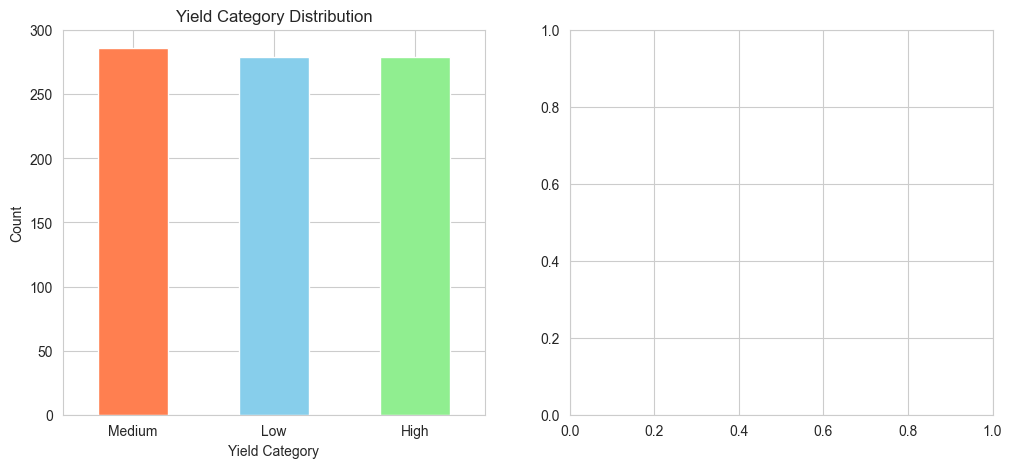

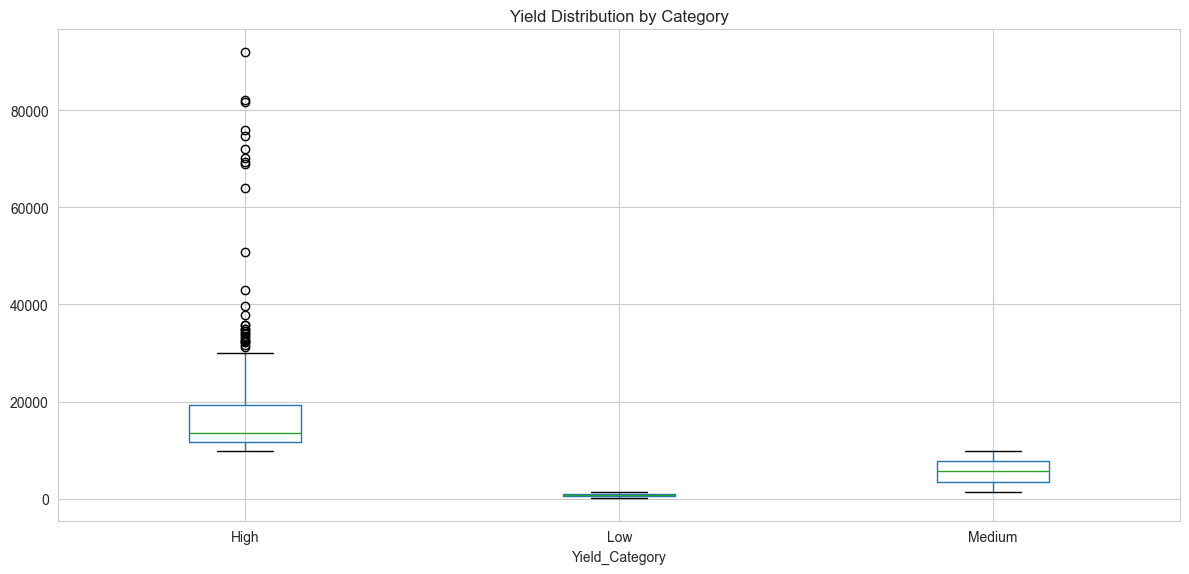

In [21]:
# Step 3: Create Yield Categories (Target Variable)
print("\n=== STEP 3: CREATE YIELD CATEGORIES ===\n")

# Define yield categories based on quantiles
yield_quantiles = modeling_df['Yield'].quantile([0.33, 0.67])
print(f"Yield quantile thresholds:")
print(f"  33rd percentile: {yield_quantiles[0.33]:.2f} kg/ha")
print(f"  67th percentile: {yield_quantiles[0.67]:.2f} kg/ha")

# Create categories
def categorize_yield(yield_val):
    if yield_val < yield_quantiles[0.33]:
        return 'Low'
    elif yield_val < yield_quantiles[0.67]:
        return 'Medium'
    else:
        return 'High'

modeling_df['Yield_Category'] = modeling_df['Yield'].apply(categorize_yield)

print(f"\nYield Category Distribution:")
print(modeling_df['Yield_Category'].value_counts().sort_index())
print(f"\nPercentages:")
print((modeling_df['Yield_Category'].value_counts(normalize=True) * 100).round(2))

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
modeling_df['Yield_Category'].value_counts().plot(kind='bar', color=['coral', 'skyblue', 'lightgreen'])
plt.title('Yield Category Distribution')
plt.xlabel('Yield Category')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
modeling_df.boxplot(column='Yield', by='Yield_Category')
plt.title('Yield Distribution by Category')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [22]:
# Step 4: Add Domain Knowledge Features
print("\n=== STEP 4: ENGINEER ADDITIONAL FEATURES ===\n")

# Crop category classification
fruits = ['Bananas', 'Avocados', 'Apples', 'Apricots', 'Coconuts', 'Mangoes', 'Oranges', 'Pineapples']
cereals = ['Barley', 'Maize', 'Wheat', 'Rice', 'Sorghum', 'Millet']
legumes = ['Beans', 'Peas', 'Cow peas', 'Chick peas', 'Lentils']
root_tubers = ['Cassava', 'Potatoes', 'Sweet potatoes', 'Yams']
vegetables = ['Cabbages', 'Carrots', 'Cucumbers', 'Tomatoes', 'Onions', 'Peppers']

def categorize_crop(crop_name):
    crop_lower = crop_name.lower()
    if any(f.lower() in crop_lower for f in fruits):
        return 'Fruits'
    elif any(c.lower() in crop_lower for c in cereals):
        return 'Cereals'
    elif any(l.lower() in crop_lower for l in legumes):
        return 'Legumes'
    elif any(rt.lower() in crop_lower for rt in root_tubers):
        return 'RootTubers'
    elif any(v.lower() in crop_lower for v in vegetables):
        return 'Vegetables'
    else:
        return 'Other'

modeling_df['Crop_Category'] = modeling_df['Item'].apply(categorize_crop)

print(f"Crop categories created:")
print(modeling_df['Crop_Category'].value_counts())

# Time-based features
modeling_df['Year_Numeric'] = modeling_df['Year']
modeling_df['Years_Since_Start'] = modeling_df['Year'] - modeling_df['Year'].min()

# Lagged features would help but require time-series setup
print(f"\nNew features added: Crop_Category, Year_Numeric, Years_Since_Start")


=== STEP 4: ENGINEER ADDITIONAL FEATURES ===

Crop categories created:
Crop_Category
Other         494
Fruits         90
Legumes        90
Vegetables     70
Cereals        60
RootTubers     40
Name: count, dtype: int64

New features added: Crop_Category, Year_Numeric, Years_Since_Start


In [23]:
# Step 5: Select Features for Modeling with Justification
print("\n=== STEP 5: FEATURE SELECTION WITH JUSTIFICATION ===\n")

feature_justification = {
    'Area harvested': 'Scale of production - crops grown on larger areas often benefit from economies of scale',
    'Years_Since_Start': 'Temporal trend - captures improvements in farming practices over time',
    'Year_Numeric': 'Year absolute value - captures long-term agricultural trends and climate patterns',
    'Crop_Category': 'Domain knowledge - different crop types have vastly different yield profiles',
    'Production': 'Aggregate metric - combines area and yield, useful for understanding total output'
}

print("SELECTED FEATURES FOR CLASSIFICATION:\n")
for feature, justification in feature_justification.items():
    print(f"• {feature:20} → {justification}")

# Features to NOT use and why
print("\n\nFEATURES EXCLUDED AND WHY:\n")
excluded = {
    'Item': 'Too many unique values (categorical encoding would be unstable)',
    'Unit': 'Constant (all kg/ha) - no variance',
    'Domain/Area/Element Code': 'Redundant with other columns',
    'Flag/Flag Description': 'Used for filtering, mixed quality acceptable, not predictive',
    'Note': 'Sparse text field, not suitable for direct modeling'
}

for feature, reason in excluded.items():
    print(f"• {feature:25} → {reason}")


=== STEP 5: FEATURE SELECTION WITH JUSTIFICATION ===

SELECTED FEATURES FOR CLASSIFICATION:

• Area harvested       → Scale of production - crops grown on larger areas often benefit from economies of scale
• Years_Since_Start    → Temporal trend - captures improvements in farming practices over time
• Year_Numeric         → Year absolute value - captures long-term agricultural trends and climate patterns
• Crop_Category        → Domain knowledge - different crop types have vastly different yield profiles
• Production           → Aggregate metric - combines area and yield, useful for understanding total output


FEATURES EXCLUDED AND WHY:

• Item                      → Too many unique values (categorical encoding would be unstable)
• Unit                      → Constant (all kg/ha) - no variance
• Domain/Area/Element Code  → Redundant with other columns
• Flag/Flag Description     → Used for filtering, mixed quality acceptable, not predictive
• Note                      → Sparse text f

In [24]:
# Step 6: Clean and Prepare Final Dataset
# print("\n=== STEP 6: FINAL DATA CLEANING ===\n")

# Create modeling dataset
model_features = ['Area harvested', 'Years_Since_Start', 'Year_Numeric', 'Crop_Category']
target = 'Yield_Category'

# Select columns
modeling_clean = modeling_df[model_features + [target] + ['Item', 'Yield', 'Production']].copy()

print(f"Final dataset shape: {modeling_clean.shape}")
print(f"Features: {model_features}")
print(f"Target: {target}")

# Check for any remaining missing values
print(f"\nMissing values in final dataset:")
print(modeling_clean.isnull().sum())

# Summary statistics by target class
print(f"\n\nMEAN VALUES BY YIELD CATEGORY:\n")
summary_by_class = modeling_clean.groupby(target)[['Area harvested', 'Years_Since_Start', 'Yield', 'Production']].mean()
print(summary_by_class.round(2))

print(f"\n\nCROP CATEGORY DISTRIBUTION BY YIELD CATEGORY:\n")
print(pd.crosstab(modeling_clean['Crop_Category'], modeling_clean['Yield_Category']))

# Save clean dataset
# modeling_clean.to_csv('yield_classifier_dataset.csv', index=False)
# print(f"\n✓ Clean dataset saved to 'yield_classifier_dataset.csv'")

Final dataset shape: (844, 8)
Features: ['Area harvested', 'Years_Since_Start', 'Year_Numeric', 'Crop_Category']
Target: Yield_Category

Missing values in final dataset:
Element
Area harvested       0
Years_Since_Start    0
Year_Numeric         0
Crop_Category        0
Yield_Category       0
Item                 0
Yield                0
Production           0
dtype: int64


MEAN VALUES BY YIELD CATEGORY:

Element         Area harvested  Years_Since_Start     Yield  Production
Yield_Category                                                         
High                  23580.35               4.62  18525.45   569275.85
Low                   89471.76               4.55    740.06    59859.95
Medium               100954.87               4.37   5555.91   270742.95


CROP CATEGORY DISTRIBUTION BY YIELD CATEGORY:

Yield_Category  High  Low  Medium
Crop_Category                    
Cereals            0   19      41
Fruits            58    6      26
Legumes           14   58      18
Other       


=== STEP 7: FEATURE-TARGET RELATIONSHIP ANALYSIS ===



C:\Users\wizar\AppData\Local\Temp\ipykernel_11076\1179907230.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([modeling_clean[modeling_clean['Yield_Category']==cat]['Area harvested'].values
C:\Users\wizar\AppData\Local\Temp\ipykernel_11076\1179907230.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([modeling_clean[modeling_clean['Yield_Category']==cat]['Production'].values


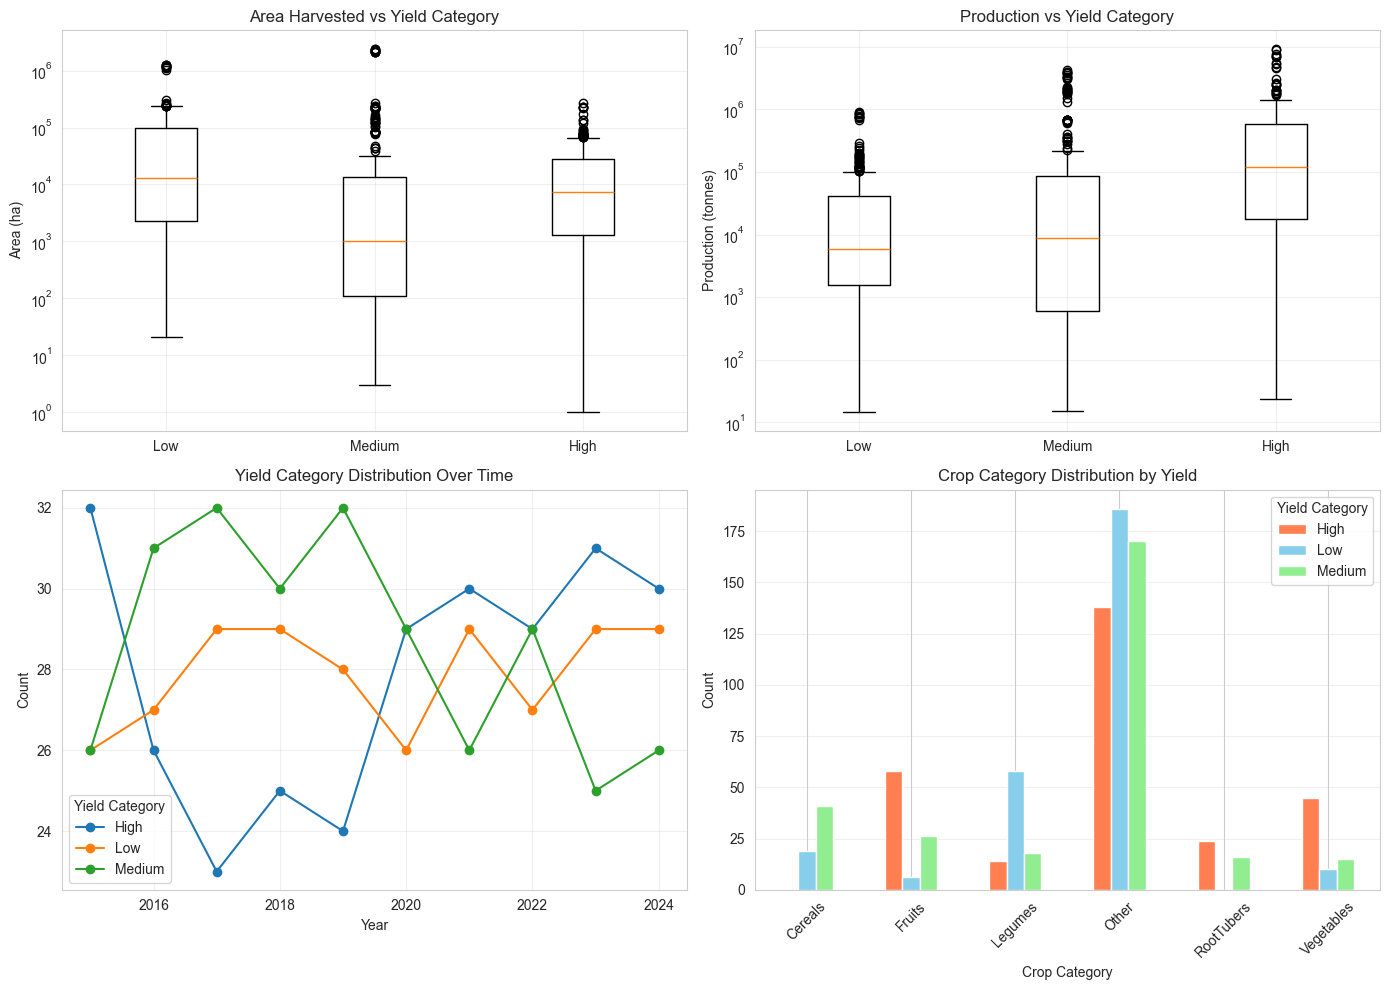

In [25]:
# Step 7: Visualize Feature Relationships
print("\n=== STEP 7: FEATURE-TARGET RELATIONSHIP ANALYSIS ===\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Area vs Yield Category
axes[0, 0].boxplot([modeling_clean[modeling_clean['Yield_Category']==cat]['Area harvested'].values 
                     for cat in ['Low', 'Medium', 'High']], 
                    labels=['Low', 'Medium', 'High'])
axes[0, 0].set_title('Area Harvested vs Yield Category')
axes[0, 0].set_ylabel('Area (ha)')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Production vs Yield Category
axes[0, 1].boxplot([modeling_clean[modeling_clean['Yield_Category']==cat]['Production'].values 
                     for cat in ['Low', 'Medium', 'High']], 
                    labels=['Low', 'Medium', 'High'])
axes[0, 1].set_title('Production vs Yield Category')
axes[0, 1].set_ylabel('Production (tonnes)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Year effect
year_yield = modeling_clean.groupby(['Year_Numeric', 'Yield_Category']).size().unstack()
year_yield.plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title('Yield Category Distribution Over Time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Yield Category')
axes[1, 0].grid(True, alpha=0.3)

# Crop Category distribution
crop_yield = pd.crosstab(modeling_clean['Crop_Category'], modeling_clean['Yield_Category'])
crop_yield.plot(kind='bar', ax=axes[1, 1], color=['coral', 'skyblue', 'lightgreen'])
axes[1, 1].set_title('Crop Category Distribution by Yield')
axes[1, 1].set_xlabel('Crop Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Yield Category')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Prepare for modeling

In [26]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("All libraries loaded ✓")


All libraries loaded ✓


#### Diagnosing the 50% Accuracy Problem

In [27]:

# ── ROOT CAUSE ANALYSIS ───────────────────────────────────────────────────────
print("=== WHY IS LR BASELINE AT ~50%? ===\n")

print("▶ 1. Perfect collinearity between year features:")
corr_val = modeling_clean[['Year_Numeric', 'Years_Since_Start']].corr().iloc[0, 1]
print(f"   corr(Year_Numeric, Years_Since_Start) = {corr_val:.6f}")
print("   → These are identical signals (one = other + constant). One must go.\n")

print("▶ 2. Area harvested skewness:")
skew_val = modeling_clean['Area harvested'].skew()
print(f"   Skewness = {skew_val:.2f}  (>1 = highly skewed; StandardScaler does NOT fix skew)")
print("   → Log-transform needed before scaling.\n")

print("▶ 3. Crop_Category is too coarse:")
print(modeling_clean['Crop_Category'].value_counts().to_string())
print("   → 'Other' swallows many crops with very different yield profiles.")
print("   → The specific crop (Item) is a far stronger signal.\n")

print("▶ 4. No cross-validation → single 80/20 split gives noisy accuracy estimate.")
print("   → StratifiedKFold CV will reveal true generalisation.\n")

print("► FIX PLAN:")
print("   • Drop Year_Numeric  (redundant with Years_Since_Start)")
print("   • Log-transform Area harvested")
print("   • Add Item as a categorical feature  ← biggest gain expected")
print("   • class_weight='balanced' in LR")
print("   • Report 5-fold CV accuracy, not just one test split")


=== WHY IS LR BASELINE AT ~50%? ===

▶ 1. Perfect collinearity between year features:
   corr(Year_Numeric, Years_Since_Start) = 1.000000
   → These are identical signals (one = other + constant). One must go.

▶ 2. Area harvested skewness:
   Skewness = 6.69  (>1 = highly skewed; StandardScaler does NOT fix skew)
   → Log-transform needed before scaling.

▶ 3. Crop_Category is too coarse:
Crop_Category
Other         494
Fruits         90
Legumes        90
Vegetables     70
Cereals        60
RootTubers     40
   → 'Other' swallows many crops with very different yield profiles.
   → The specific crop (Item) is a far stronger signal.

▶ 4. No cross-validation → single 80/20 split gives noisy accuracy estimate.
   → StratifiedKFold CV will reveal true generalisation.

► FIX PLAN:
   • Drop Year_Numeric  (redundant with Years_Since_Start)
   • Log-transform Area harvested
   • Add Item as a categorical feature  ← biggest gain expected
   • class_weight='balanced' in LR
   • Report 5-fold C

In [28]:
modeling_clean.head()

Element,Area harvested,Years_Since_Start,Year_Numeric,Crop_Category,Yield_Category,Item,Yield,Production
0,40.0,0,2015,Other,Low,"Abaca, manila hemp, raw",1208.1,48.3240
1,42.0,1,2016,Other,Low,"Abaca, manila hemp, raw",1132.9,47.5818
2,42.0,2,2017,Other,Low,"Abaca, manila hemp, raw",1135.1,47.6742
3,42.0,3,2018,Other,Low,"Abaca, manila hemp, raw",1149.4,48.2748
4,43.0,4,2019,Other,Low,"Abaca, manila hemp, raw",1143.9,49.1877


In [29]:

# ── IMPROVED FEATURE ENGINEERING ─────────────────────────────────────────────
# Log-transform Area harvested (highly right-skewed → hurts linear models)
modeling_clean = modeling_clean.copy()
modeling_clean['log_Area'] = np.log1p(modeling_clean['Area harvested'])

# Updated feature set  ── drop Year_Numeric (perfectly collinear with Years_Since_Start)
#                      ── add Item (crop name) for fine-grained crop signal
model_features_v2 = ['log_Area', 'Years_Since_Start', 'Crop_Category', 'Item']
target = 'Yield_Category'

X = modeling_clean[model_features_v2]
y = modeling_clean[target]

print(f"Feature set  : {model_features_v2}")
print(f"X shape      : {X.shape}")
print(f"y shape      : {y.shape}")
print(f"\nTarget distribution (should be ~33% each by construction):")
print(y.value_counts())
print(f"\n{y.value_counts(normalize=True).mul(100).round(1).to_string()} %")


Feature set  : ['log_Area', 'Years_Since_Start', 'Crop_Category', 'Item']
X shape      : (844, 4)
y shape      : (844,)

Target distribution (should be ~33% each by construction):
Yield_Category
Medium    286
Low       279
High      279
Name: count, dtype: int64

Yield_Category
Medium    33.9
Low       33.1
High      33.1 %


Baseline

In [30]:

# ── PREPROCESSOR ─────────────────────────────────────────────────────────────
numeric_features     = ['log_Area', 'Years_Since_Start']
categorical_features = ['Crop_Category', 'Item']     # Item = specific crop name

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        # handle_unknown='ignore': unseen crop names in test fold won't break the model
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop'
)

print("Preprocessor:")
print(f"  Numeric      → StandardScaler       : {numeric_features}")
print(f"  Categorical  → OneHotEncoder        : {categorical_features}")
print("  handle_unknown='ignore'  → robust to unseen items in test folds")


Preprocessor:
  Numeric      → StandardScaler       : ['log_Area', 'Years_Since_Start']
  Categorical  → OneHotEncoder        : ['Crop_Category', 'Item']
  handle_unknown='ignore'  → robust to unseen items in test folds


**Baseline — Logistic Regression (multinomial)**  
LR is a good baseline because it is interpretable, fast, and provides a linear decision boundary.  
`class_weight='balanced'` corrects for any residual class skew.  
We evaluate using **5-fold Stratified CV** (not a single train/test split) for a robust estimate.  
If LR plateaus, non-linear models (XGBoost, RF) will be explored next.

In [32]:

# ── LOGISTIC REGRESSION PIPELINE ─────────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight='balanced',   # handles residual class imbalance
        # multi_class='multinomial', # explicit multinomial (vs one-vs-rest)
        solver='lbfgs',
        C=1.0
    ))
])

print("LR pipeline ready  ─  multinomial, balanced, max_iter=2000")


LR pipeline ready  ─  multinomial, balanced, max_iter=2000


In [33]:

# ── STRATIFIED SPLIT ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify preserves class proportions
)

print(f"Train : {X_train.shape[0]} samples   |   Test : {X_test.shape[0]} samples")
print(f"\nTrain class split:\n{y_train.value_counts().to_string()}")
print(f"\nTest  class split:\n{y_test.value_counts().to_string()}")

# ── 5-FOLD STRATIFIED CROSS-VALIDATION (on training set) ─────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    lr_pipeline, X_train, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'f1_weighted'],
    return_train_score=True,
    n_jobs=-1
)

print("\n══════════════════════════════════════════════════")
print("  5-FOLD CV — LOGISTIC REGRESSION BASELINE")
print("══════════════════════════════════════════════════")
print(f"  Train Accuracy   : {cv_results['train_accuracy'].mean():.3f} ± {cv_results['train_accuracy'].std():.3f}")
print(f"  Val   Accuracy   : {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"  Val   F1 Macro   : {cv_results['test_f1_macro'].mean():.3f} ± {cv_results['test_f1_macro'].std():.3f}")
print(f"  Val   F1 Weighted: {cv_results['test_f1_weighted'].mean():.3f} ± {cv_results['test_f1_weighted'].std():.3f}")

high_gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"\n  Train-Val gap    : {high_gap:.3f}  {'← overfitting if > 0.10' if high_gap > 0.10 else '← looks healthy'}")

# ── FINAL FIT ON FULL TRAINING SET ─────────────────────────────────────────
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
print("\nFinal model fitted on full training set ✓")


Train : 675 samples   |   Test : 169 samples

Train class split:
Yield_Category
Medium    229
Low       223
High      223

Test  class split:
Yield_Category
Medium    57
High      56
Low       56

══════════════════════════════════════════════════
  5-FOLD CV — LOGISTIC REGRESSION BASELINE
══════════════════════════════════════════════════
  Train Accuracy   : 0.920 ± 0.003
  Val   Accuracy   : 0.884 ± 0.014
  Val   F1 Macro   : 0.885 ± 0.014
  Val   F1 Weighted: 0.884 ± 0.014

  Train-Val gap    : 0.035  ← looks healthy

Final model fitted on full training set ✓


In [40]:
675 + 169

844

══════════════════════════════════════════════════
  TEST SET — LOGISTIC REGRESSION BASELINE
══════════════════════════════════════════════════
  Accuracy  : 0.911
  F1 Macro  : 0.911

Classification Report:

              precision    recall  f1-score   support

        High       0.86      0.89      0.88        56
         Low       0.98      1.00      0.99        56
      Medium       0.89      0.84      0.86        57

    accuracy                           0.91       169
   macro avg       0.91      0.91      0.91       169
weighted avg       0.91      0.91      0.91       169



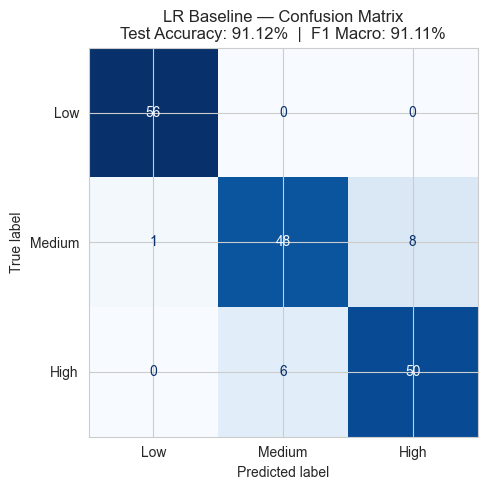

In [34]:

# ── TEST-SET EVALUATION — LOGISTIC REGRESSION ─────────────────────────────────
lr_test_acc = accuracy_score(y_test, y_pred_lr)
lr_f1_macro = f1_score(y_test, y_pred_lr, average='macro')

print("══════════════════════════════════════════════════")
print("  TEST SET — LOGISTIC REGRESSION BASELINE")
print("══════════════════════════════════════════════════")
print(f"  Accuracy  : {lr_test_acc:.3f}")
print(f"  F1 Macro  : {lr_f1_macro:.3f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=['High', 'Low', 'Medium']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'LR Baseline — Confusion Matrix\nTest Accuracy: {lr_test_acc:.2%}  |  F1 Macro: {lr_f1_macro:.2%}')
plt.tight_layout()
plt.show()


#### XGBoost Classifier — Gradient Boosting with SMOTE

**Why XGBoost?**
- Handles non-linear feature interactions that LR cannot capture
- Built-in regularisation (L1/L2) prevents overfitting on small datasets
- Feature importance is interpretable
- Robust to class imbalance (scale_pos_weight or SMOTE)

**Why SMOTE?**
- Even though classes look balanced ~33% each by construction, SMOTE on training folds adds slight robustness to minority over-representation caused by the random split.
- Wrapped inside `ImbPipeline` so SMOTE is only applied to training folds — **no leakage**.

In [35]:
# ── LABEL ENCODE TARGET for XGBoost (needs integer labels) ───────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── XGBOOST PIPELINE (preprocessor → SMOTE → XGBoost) ───────────────────────
# ImbPipeline ensures SMOTE is only applied inside training folds
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

print("\nXGBoost pipeline (preprocessor → SMOTE → XGBClassifier) ready ✓")


Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

XGBoost pipeline (preprocessor → SMOTE → XGBClassifier) ready ✓


══════════════════════════════════════════════════
  5-FOLD CV — XGBOOST + SMOTE
══════════════════════════════════════════════════
  Train Accuracy   : 0.955 ± 0.006
  Val   Accuracy   : 0.880 ± 0.029
  Val   F1 Macro   : 0.880 ± 0.029
  Val   F1 Weighted: 0.879 ± 0.029

  Train-Val gap    : 0.075  ← healthy

══════════════════════════════════════════════════
  TEST SET — XGBOOST + SMOTE
══════════════════════════════════════════════════
  Accuracy  : 0.911
  F1 Macro  : 0.911

Classification Report:

              precision    recall  f1-score   support

        High       0.86      0.89      0.88        56
         Low       0.98      1.00      0.99        56
      Medium       0.89      0.84      0.86        57

    accuracy                           0.91       169
   macro avg       0.91      0.91      0.91       169
weighted avg       0.91      0.91      0.91       169



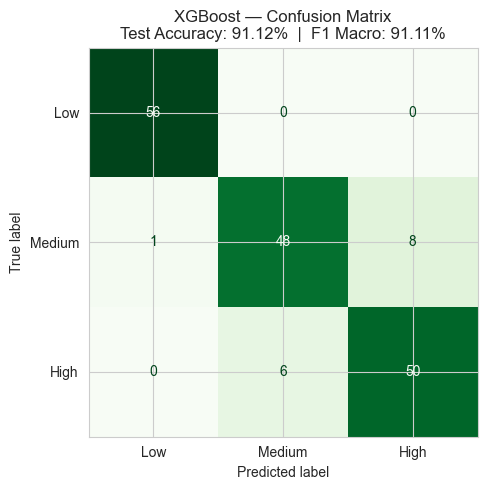

In [ ]:
# ── 5-FOLD CV — XGBOOST ──────────────────────────────────────────────────────
# Use integer-encoded y for XGBoost pipeline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = cross_validate(
    xgb_pipeline, X_train, y_train_enc,
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'f1_weighted'],
    return_train_score=True,
    n_jobs=-1
)

print("══════════════════════════════════════════════════")
print("  5-FOLD CV — XGBOOST + SMOTE")
print("══════════════════════════════════════════════════")
print(f"  Train Accuracy   : {xgb_cv['train_accuracy'].mean():.3f} ± {xgb_cv['train_accuracy'].std():.3f}")
print(f"  Val   Accuracy   : {xgb_cv['test_accuracy'].mean():.3f} ± {xgb_cv['test_accuracy'].std():.3f}")
print(f"  Val   F1 Macro   : {xgb_cv['test_f1_macro'].mean():.3f} ± {xgb_cv['test_f1_macro'].std():.3f}")
print(f"  Val   F1 Weighted: {xgb_cv['test_f1_weighted'].mean():.3f} ± {xgb_cv['test_f1_weighted'].std():.3f}")

gap = xgb_cv['train_accuracy'].mean() - xgb_cv['test_accuracy'].mean()
print(f"\n  Train-Val gap    : {gap:.3f}  {'← slight overfit; try lower max_depth or more regularisation' if gap > 0.15 else '← healthy'}")

# ── FIT ON FULL TRAINING SET ─────────────────────────────────────────────────
xgb_pipeline.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

xgb_test_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1_macro = f1_score(y_test, y_pred_xgb, average='macro')

print("\n══════════════════════════════════════════════════")
print("  TEST SET — XGBOOST + SMOTE")
print("══════════════════════════════════════════════════")
print(f"  Accuracy  : {xgb_test_acc:.3f}")
print(f"  F1 Macro  : {xgb_f1_macro:.3f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=sorted(y.unique())))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Low', 'Medium', 'High'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'XGBoost — Confusion Matrix\nTest Accuracy: {xgb_test_acc:.2%}  |  F1 Macro: {xgb_f1_macro:.2%}')
plt.tight_layout()
plt.show()


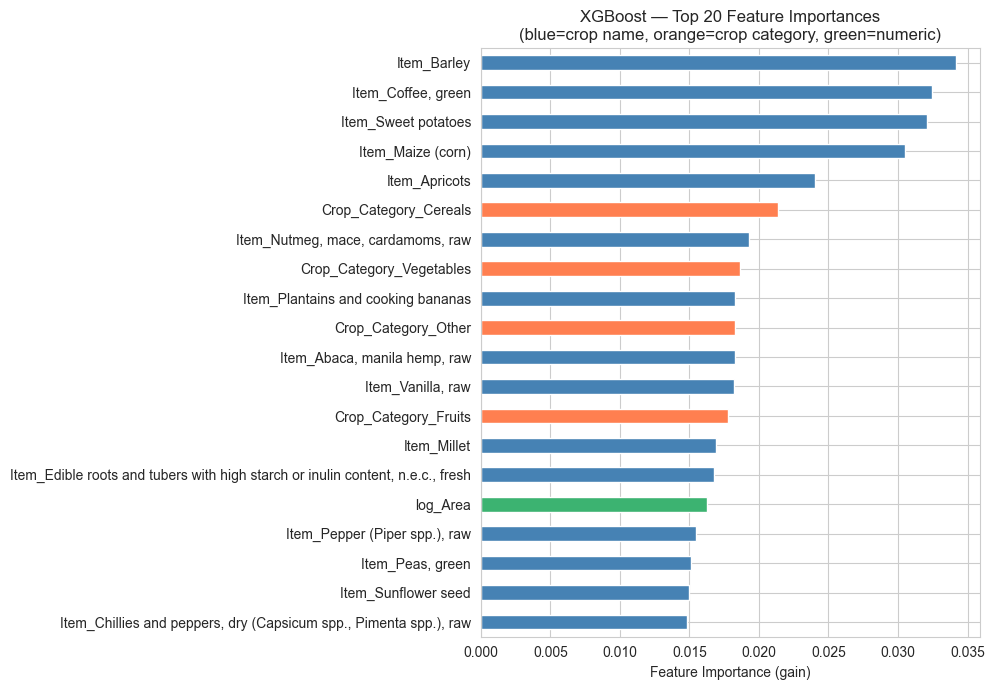


Top 10 most important features:
  Item_Barley                                    0.0342
  Item_Coffee, green                             0.0324
  Item_Sweet potatoes                            0.0321
  Item_Maize (corn)                              0.0305
  Item_Apricots                                  0.0240
  Crop_Category_Cereals                          0.0214
  Item_Nutmeg, mace, cardamoms, raw              0.0193
  Crop_Category_Vegetables                       0.0187
  Item_Plantains and cooking bananas             0.0183
  Crop_Category_Other                            0.0183


In [37]:

# ── FEATURE IMPORTANCE — XGBOOST ─────────────────────────────────────────────
xgb_clf = xgb_pipeline.named_steps['classifier']
ohe      = xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat']

# Reconstruct feature names
num_names = ['log_Area', 'Years_Since_Start']
cat_names = list(ohe.get_feature_names_out(['Crop_Category', 'Item']))
all_feature_names = num_names + cat_names

importances = xgb_clf.feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

# Top 20 features
top_n = 20
top_feats = feat_imp.head(top_n)

plt.figure(figsize=(10, 7))
colors = ['steelblue' if 'Item' in f else ('coral' if 'Crop_Category' in f else 'mediumseagreen')
          for f in top_feats.index]
top_feats.sort_values().plot(kind='barh', color=colors[::-1])
plt.xlabel('Feature Importance (gain)')
plt.title(f'XGBoost — Top {top_n} Feature Importances\n'
          '(blue=crop name, orange=crop category, green=numeric)')
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features:")
for feat, imp in feat_imp.head(10).items():
    print(f"  {feat:45s}  {imp:.4f}")


#### Model Comparison Summary

══════════════════════════════════════════════════════════════
  MODEL COMPARISON SUMMARY
══════════════════════════════════════════════════════════════
                     CV Acc (mean)  CV Acc (std)  CV F1 Macro  Test Acc  Test F1 Macro
Logistic Regression          0.884         0.014        0.885     0.911          0.911
XGBoost + SMOTE              0.880         0.029        0.880     0.911          0.911


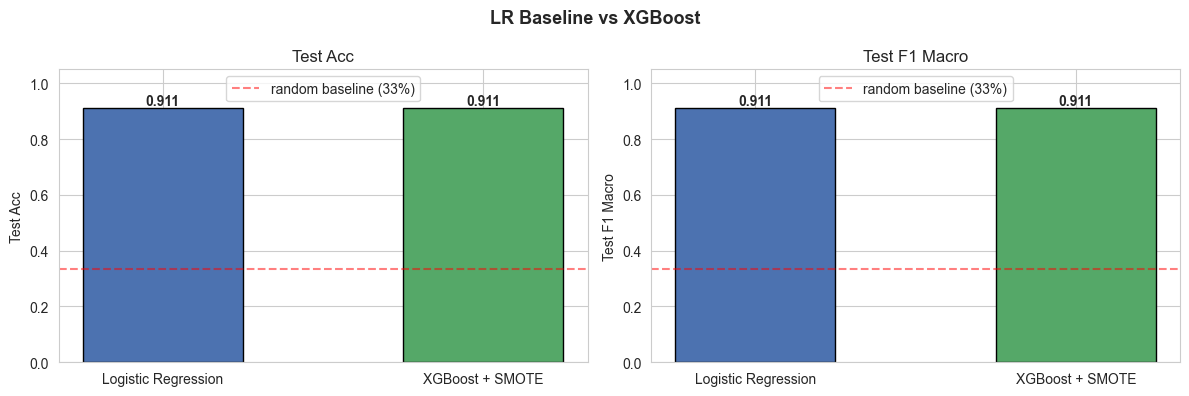


✓ Improvement over random guessing (33.3%): 173.6% gain


In [38]:

# ── SIDE-BY-SIDE COMPARISON ───────────────────────────────────────────────────
results = {
    'Logistic Regression': {
        'CV Acc (mean)': cv_results['test_accuracy'].mean(),
        'CV Acc (std)':  cv_results['test_accuracy'].std(),
        'CV F1 Macro':   cv_results['test_f1_macro'].mean(),
        'Test Acc':      lr_test_acc,
        'Test F1 Macro': lr_f1_macro,
    },
    'XGBoost + SMOTE': {
        'CV Acc (mean)': xgb_cv['test_accuracy'].mean(),
        'CV Acc (std)':  xgb_cv['test_accuracy'].std(),
        'CV F1 Macro':   xgb_cv['test_f1_macro'].mean(),
        'Test Acc':      xgb_test_acc,
        'Test F1 Macro': xgb_f1_macro,
    },
}

comparison_df = pd.DataFrame(results).T.round(3)
print("══════════════════════════════════════════════════════════════")
print("  MODEL COMPARISON SUMMARY")
print("══════════════════════════════════════════════════════════════")
print(comparison_df.to_string())

# Visual bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics_to_plot = ['CV Acc (mean)', 'Test Acc', 'Test F1 Macro']
colors = ['#4C72B0', '#55A868']

for i, metric in enumerate(['Test Acc', 'Test F1 Macro']):
    yvals = [results[m][metric] for m in results]
    axes[i].bar(list(results.keys()), yvals, color=colors, edgecolor='black', width=0.5)
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel(metric)
    axes[i].set_title(metric)
    for j, v in enumerate(yvals):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
    axes[i].axhline(0.333, color='red', linestyle='--', alpha=0.5, label='random baseline (33%)')
    axes[i].legend()

plt.suptitle('LR Baseline vs XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Improvement over random guessing (33.3%):", end=" ")
best = max(lr_test_acc, xgb_test_acc)
print(f"{(best - 0.333) / 0.333 * 100:.1f}% gain")


In [39]:
# save xgboost model for future use
import joblib
joblib.dump(xgb_pipeline, 'xgb_yield_classifier.pkl')
print("\n✓ XGBoost model saved to 'xgb_yield_classifier.pkl'")


✓ XGBoost model saved to 'xgb_yield_classifier.pkl'


In [ ]:
# import saved xgboost model for use
loaded_xgb = joblib.load('xgb_yield_classifier.pkl')
y_pred_loaded = loaded_xgb.predict(X_test)